# FX Option Backtesting - USDJPY

Notebook end-to-end pour charger les donnees Parquet, construire le moteur de pricing Garman-Kohlhagen, executer une strategie multi-leg delta-hedgee, puis analyser les performances.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from fx_backtester import BacktestConfig, MarketData, OptionBacktester, StrategyFactory, performance_report
from fx_backtester.plots import plot_backtest

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Load and inspect market data

The raw files are stacked. The `MarketData` class cleans the numeric fields, converts dates, pivots the curves by date/maturity, and unpacks volatility surfaces by date/maturity for efficient lookup.

In [2]:
market = MarketData.from_folder(ROOT)

summary = pd.DataFrame({
    'dataset': ['spot', 'forward curve', 'domestic JPY rates', 'foreign USD rates', 'vol surface'],
    'rows': [len(market.spot), len(market.forwards), len(market.domestic_rates), len(market.foreign_rates), len(market.vols)],
    'start': [market.spot.index.min(), market.forwards.DATE.min(), market.domestic_rates.DATE.min(), market.foreign_rates.DATE.min(), market.vols.DATE.min()],
    'end': [market.spot.index.max(), market.forwards.DATE.max(), market.domestic_rates.DATE.max(), market.foreign_rates.DATE.max(), market.vols.DATE.max()],
})
summary

,dataset,rows,start,end
0,spot,5799,2003-12-31,2026-03-23
1,forward curve,170889,2003-12-31,2026-03-23
2,domestic JPY rates,97627,2003-12-31,2026-03-23
3,foreign USD rates,124171,2003-12-31,2026-03-23
4,vol surface,1822373,2006-03-30,2026-03-23


## 2. Check pricing inputs

For USDJPY, JPY is domestic and USD is foreign. Forward points are divided by 100 before being added to spot.

In [3]:
sample_date = pd.Timestamp('2024-01-02')
sample_maturity = sample_date + pd.DateOffset(months=1)

pd.Series({
    'spot': market.spot_on(sample_date),
    '1M forward outright': market.forward_outright(sample_date, sample_maturity),
    'domestic JPY rate': market.domestic_rate(sample_date, sample_maturity),
    'foreign USD rate': market.foreign_rate(sample_date, sample_maturity),
    'ATM vol estimate': market.volatility(sample_date, sample_maturity, market.forward_outright(sample_date, sample_maturity)),
})

spot                  141.9850
1M forward outright   141.3580
domestic JPY rate      -0.0024
foreign USD rate        0.0545
ATM vol estimate        0.1078
dtype: float64

## 3. Run the main strategy

The main quantitative analysis uses a 1-month ATM-forward straddle, rolled monthly, with daily delta hedging. P&L is expressed in JPY.

In [4]:
config = BacktestConfig(
    start='2024-01-02',
    end='2025-12-31',
    roll_frequency='monthly',
    notional=1_000_000,
    signal_mode='always',
)

strategy = StrategyFactory.straddle(tenor_months=1)
results = OptionBacktester(market, config).run(strategy)
results.head()

,spot,option_value,delta,gamma,vega,theta,implied_vol,hedge_units,hedge_value,cash,nav,total_pnl,option_pnl,hedge_pnl,delta_attr,gamma_attr,vega_attr,theta_attr
date,,,,,,,,,,,,,,,,,,
2024-01-02,141.9850,"3,544,847.4792","2,271.7388","177,977.6030","32,862,801.3750","-57,133.4646",0.1078,"-2,271.7388","-322,552.8398","-3,222,294.6394",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2024-01-03,143.2950,"3,771,738.9812","231,408.3274","165,605.6594","31,237,647.5992","-53,070.7106",0.1118,"-231,408.3274","-33,159,656.2788","29,611,832.8217","223,915.5241","223,915.5241","226,891.5020","-2,975.9779","2,975.9779","152,713.6823","128,998.9146","-57,133.4646"
2024-01-04,144.6300,"4,296,319.1841","436,963.0450","142,055.8942","27,357,082.6523","-45,011.5950",0.1159,"-436,963.0450","-63,197,965.1964","59,341,211.6222","439,565.6099","215,650.0859","524,580.2030","-308,930.1171","308,930.1171","147,573.2732","128,322.1723","-53,070.7106"
2024-01-05,144.6650,"4,156,731.8550","465,381.7301","146,103.1701","26,207,337.2286","-41,982.6192",0.1117,"-465,381.7301","-67,324,447.9915","63,452,400.7107","284,684.5742","-154,881.0357","-139,587.3291","-15,293.7066","15,293.7066",87.0092,"-113,377.3713","-45,011.5950"
2024-01-08,144.2300,"3,838,088.7961","430,245.4154","159,695.6768","25,497,770.5750","-47,723.2354",0.1121,"-430,245.4154","-62,054,296.2631","58,384,690.0349","168,482.5679","-116,202.0063","-318,643.0589","202,441.0526","-202,441.0526","13,823.1862","8,639.8676","-41,982.6192"


In [5]:
report = performance_report(results)
report

total_pnl                     -3,614,939.7529
annualized_pnl                -1,745,143.3290
annualized_vol                 3,059,439.7928
sharpe                                -0.5704
sortino                               -1.0504
hit_ratio                              0.4215
max_drawdown                  -6,253,353.9915
var_95_daily                    -253,368.8565
expected_shortfall_95_daily     -354,442.9131
dtype: float64

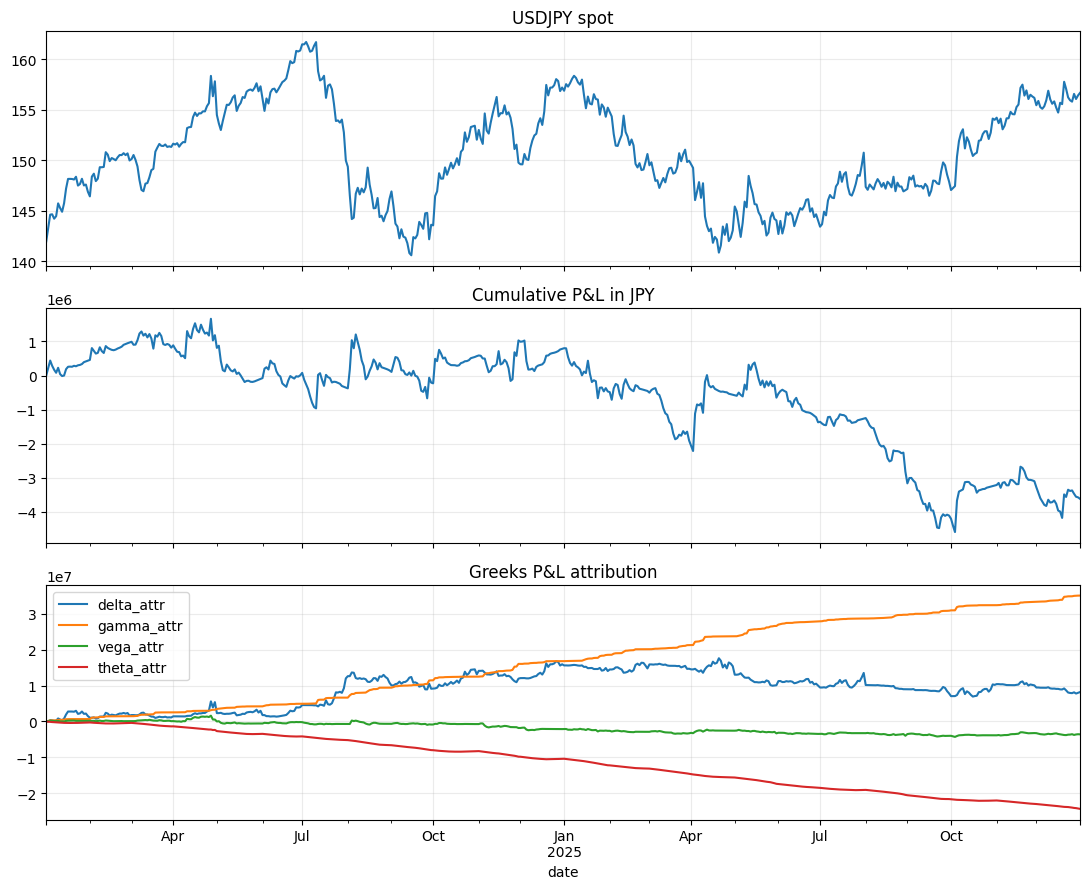

In [6]:
fig = plot_backtest(results)
fig.savefig(OUTPUTS / 'notebook_straddle_charts.png', dpi=150)
plt.show()

## 4. Greeks P&L attribution

The attribution uses previous-day Greeks to approximate the daily P&L drivers: Delta, Gamma, Vega, and Theta.

In [7]:
attr_cols = ['delta_attr', 'gamma_attr', 'vega_attr', 'theta_attr']
attribution = results[attr_cols].sum().sort_values()
attribution

theta_attr   -24,371,011.8149
vega_attr     -3,585,955.0210
delta_attr     8,204,346.5787
gamma_attr    35,125,971.5512
dtype: float64

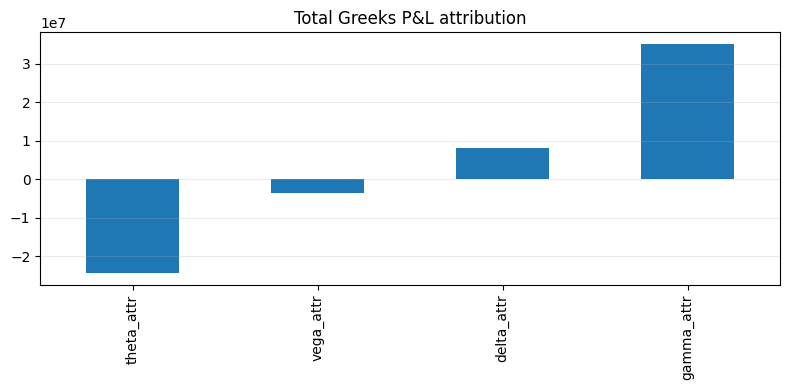

In [8]:
ax = attribution.plot(kind='bar', figsize=(8, 4), title='Total Greeks P&L attribution')
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUTS / 'notebook_greeks_attribution.png', dpi=150)
plt.show()

## 5. Multi-leg examples

The same engine can run other structures, such as a call ratio spread or a calendar call spread.

In [9]:
examples = {
    'straddle': StrategyFactory.straddle(tenor_months=1),
    'ratio_call_spread': StrategyFactory.ratio_call_spread(tenor_months=1),
    'calendar_call_spread': StrategyFactory.calendar_call_spread(front_months=1, back_months=3),
}

comparison = {}
for name, legs in examples.items():
    res = OptionBacktester(market, config).run(legs)
    comparison[name] = performance_report(res)

pd.DataFrame(comparison).T

,total_pnl,annualized_pnl,annualized_vol,sharpe,sortino,hit_ratio,max_drawdown,var_95_daily,expected_shortfall_95_daily
straddle,"-3,614,939.7529","-1,745,143.3290","3,059,439.7928",-0.5704,-1.0504,0.4215,"-6,253,353.9915","-253,368.8565","-354,442.9131"
ratio_call_spread,"4,074,413.9248","1,966,958.4465","2,469,819.6231",0.7964,0.7478,0.5441,"-2,674,121.1543","-169,790.4534","-378,033.1919"
calendar_call_spread,"3,440,427.5270","1,660,896.0475","1,016,361.0008",1.6342,2.1794,0.5479,"-801,451.0510","-86,699.0238","-148,515.4823"


## 6. Signal integration

The optional signal enters only after a sufficiently large 20-day absolute spot move. This is deliberately simple and transparent.

In [10]:
signal_config = BacktestConfig(
    start='2024-01-02',
    end='2025-12-31',
    roll_frequency='monthly',
    notional=1_000_000,
    signal_mode='spot_momentum',
    momentum_lookback=20,
    momentum_threshold=0.015,
)

signal_results = OptionBacktester(market, signal_config).run(strategy)
pd.DataFrame({
    'always_in': performance_report(results),
    'momentum_signal': performance_report(signal_results),
}).T

,total_pnl,annualized_pnl,annualized_vol,sharpe,sortino,hit_ratio,max_drawdown,var_95_daily,expected_shortfall_95_daily
always_in,"-3,614,939.7529","-1,745,143.3290","3,059,439.7928",-0.5704,-1.0504,0.4215,"-6,253,353.9915","-253,368.8565","-354,442.9131"
momentum_signal,"-5,968,890.3295","-2,881,533.2625","2,902,151.5790",-0.9929,-1.5237,0.3352,"-7,591,963.3168","-260,814.1202","-387,830.0029"


## 7. Save outputs

The CSV outputs can be reused for the written quantitative analysis.

In [11]:
results.to_csv(OUTPUTS / 'notebook_straddle_results.csv')
report.to_csv(OUTPUTS / 'notebook_straddle_report.csv', header=['value'])
print(f'Saved notebook outputs to {OUTPUTS}')

Saved notebook outputs to C:\Users\Lia\OneDrive - Université Paris 1 Panthéon-Sorbonne\Bureau\dauphine\FX_option\outputs


## Economic rationale

A long straddle is long realized movement and long implied volatility, but short carry through Theta. With daily delta hedging, the strategy can gain when spot movements are large enough for Gamma gains to offset premium decay. It can lose in quiet markets, after volatility compression, or when transaction costs are introduced. For this reason, option-specific diagnostics such as tail risk, drawdown, and Greeks attribution are more informative than Sharpe ratio alone.